# Data exploration

First pass on the 14-ticker universe before any of this becomes
`fetch_data.py`. Goal here is just to get comfortable with the raw
yfinance output, check it's clean enough to build on, and eyeball
returns/correlations before writing the pipeline for real.

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
from scipy import stats
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
from src.config import SupabaseConfig
from src.universe import TICKERS, PORTFOLIO_NAME, PORTFOLIO_DESCRIPTION
from src.risk_config import DATA_START_DATE

## Pull price history

In [3]:
tickers = list(TICKERS.keys())
END_DATE = None  # None = up to today

raw_data = yf.download(
    tickers=tickers,
    start=DATA_START_DATE,
    end=END_DATE,
    group_by="ticker",
    auto_adjust=True,
    threads=True
)

[*********************100%***********************]  14 of 14 completed


In [4]:
raw_data

Ticker             JNJ                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2005-01-03   34.397962   34.506559   34.039594   34.153622  7859500   
2005-01-04   34.262205   34.338225   34.001574   34.045013  6989600   
2005-01-05   34.137334   34.256791   33.985299   34.023308  6888100   
2005-01-06   34.072168   34.256782   34.039588   34.121037  5277500   
2005-01-07   34.197054   34.207914   33.974431   33.996151  5037800   
...                ...         ...         ...         ...      ...   
2026-08-10  259.059998  262.000000  258.549988  261.809998  8985100   
2026-08-11  261.230011  264.149994  258.359985  259.799988  5945900   
2026-08-12  256.000000  261.410004  255.259995  260.859985  4629300   
2026-08-13  261.730011  262.619995  259.649994  262.079987  4852700   
2026-08-14  260.649994  261.709991  259.160004  260.350006  4998100   

Ticker            MDT                                            ...  \
Price            Open       High        Low      Close   Volume  ...   
Date                                                             ...   
2005-01-03  30.999812  31.056062  30.793565  30.893564  3249800  ...   
2005-01-04  30.937300  30.937300  30.649802  30.749802  4320500  ...   
2005-01-05  30.677804  30.865626  30.515024  30.521284  3600000  ...   
2005-01-06  30.489973  31.272570  30.489973  31.147354  5396700  ...   
2005-01-07  31.003361  31.767177  30.990840  31.429094  5868800  ...   
...               ...        ...        ...        ...      ...  ...   
2026-08-10  87.160004  89.449997  86.720001  89.410004  6572300  ...   
2026-08-11  89.260002  90.730003  88.699997  90.680000  8392200  ...   
2026-08-12  88.959999  91.029999  88.500000  90.760002  6231800  ...   
2026-08-13  91.440002  91.610001  90.410004  90.580002  6475800  ...   
2026-08-14  90.989998  91.989998  90.410004  91.269997  8245200  ...   

Ticker             DIS                                               \
Price             Open        High         Low       Close   Volume   
Date                                                                  
2005-01-03   21.892335   22.246581   21.892335   21.923824  5698936   
2005-01-04   22.215098   22.215098   21.664050   21.687668  5893969   
2005-01-05   21.845107   21.845107   21.561710   21.569582  5454638   
2005-01-06   21.593202   21.931704   21.538099   21.601074  5606893   
2005-01-07   21.648300   21.679788   21.294056   21.388521  6624430   
...                ...         ...         ...         ...      ...   
2026-08-10  104.610001  104.800003  102.800003  103.180000  8631900   
2026-08-11  102.949997  104.089996  102.790001  103.529999  6781600   
2026-08-12  103.290001  103.680000  102.029999  103.220001  6717500   
2026-08-13  103.800003  104.940002  103.459999  104.800003  7100000   
2026-08-14  104.989998  107.110001  104.910004  106.849998  8172300   

Ticker            AAPL                                                  
Price             Open        High         Low       Close      Volume  
Date                                                                    
2005-01-03    0.968773    0.973708    0.936171    0.946491   691992000  
2005-01-04    0.953968    0.979092    0.941704    0.956211  1096810400  
2005-01-05    0.963987    0.975802    0.957855    0.964585   680433600  
2005-01-06    0.967128    0.970717    0.947089    0.965334   705555200  
2005-01-07    0.972063    1.041304    0.968325    1.035621  2227450400  
...                ...         ...         ...         ...         ...  
2026-08-10  306.829987  308.260010  304.609985  308.260010    44812500  
2026-08-11  307.750000  309.970001  302.790009  304.910004    37476700  
2026-08-12  305.100006  305.660004  300.570007  302.250000    41657800  
2026-08-13  304.209991  306.000000  302.049988  305.260010    40349300  
2026-08-14  306.000000  307.489990  304.299988  305.

In [5]:
print(raw_data.isna().sum().to_string())

Ticker  Price 
JNJ     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
MDT     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
WMT     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
GS      Open      0
        High      0
        Low       0
        Close     0
        Volume    0
F       Open      0
        High      0
        Low       0
        Close     0
        Volume    0
NEE     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
PG      Open      0
        High      0
        Low       0
        Close     0
        Volume    0
XOM     Open      0
        High      0
        Low       0
        Close     0
        Volume    0
MSFT    Open      0
        High      0
        Low       0
        Close     0
        Volume    0
NEM     Open      0
        High      0
        Low       0
        Close     0
     

## Reshape to long format

yfinance gives back a wide frame (ticker x OHLCV columns). Everything
downstream wants one row per (date, ticker), so unstack it once here.

In [6]:
prices_stacked = raw_data.stack('Ticker', future_stack=True)
prices_stacked

Price                    Open        High         Low       Close    Volume
Date       Ticker                                                          
2005-01-03 JNJ      34.397962   34.506559   34.039594   34.153622   7859500
           MDT      30.999812   31.056062   30.793565   30.893564   3249800
           WMT      11.755389   11.875676   11.656971   11.667906  48235200
           GS       74.969343   75.219478   74.569122   75.005074   4225300
           F         6.776255    6.817855    6.706921    6.799366   9852200
...                       ...         ...         ...         ...       ...
2026-08-14 NEM     115.800003  119.169998  115.320000  117.760002   5577800
           CAT     854.000000  870.989990  850.000000  856.570007   1893400
           JPM     363.000000  365.899994  361.450012  362.839996   5058000
           DIS     104.989998  107.110001  104.910004  106.849998   8172300
           AAPL    306.000000  307.489990  304.299988  305.929993  28186700

[76132 rows x 5 columns]

In [7]:
prices_long = prices_stacked.reset_index()
prices_long

Price,Date,Ticker,Open,High,Low,Close,Volume
0,2005-01-03,JNJ,34.397962,34.506559,34.039594,34.153622,7859500
1,2005-01-03,MDT,30.999812,31.056062,30.793565,30.893564,3249800
2,2005-01-03,WMT,11.755389,11.875676,11.656971,11.667906,48235200
3,2005-01-03,GS,74.969343,75.219478,74.569122,75.005074,4225300
4,2005-01-03,F,6.776255,6.817855,6.706921,6.799366,9852200
...,...,...,...,...,...,...,...
76127,2026-08-14,NEM,115.800003,119.169998,115.320000,117.760002,5577800
76128,2026-08-14,CAT,854.000000,870.989990,850.000000,856.570007,1893400
76129,2026-08-14,JPM,363.000000,365.899994,361.450012,362.839996,5058000
76130,2026-08-14,DIS,104.989998,107.110001,104.910004,106.849998,8172300


In [8]:
prices_long = prices_long.rename(columns = str.lower)
prices_long

Price,date,ticker,open,high,low,close,volume
0,2005-01-03,JNJ,34.397962,34.506559,34.039594,34.153622,7859500
1,2005-01-03,MDT,30.999812,31.056062,30.793565,30.893564,3249800
2,2005-01-03,WMT,11.755389,11.875676,11.656971,11.667906,48235200
3,2005-01-03,GS,74.969343,75.219478,74.569122,75.005074,4225300
4,2005-01-03,F,6.776255,6.817855,6.706921,6.799366,9852200
...,...,...,...,...,...,...,...
76127,2026-08-14,NEM,115.800003,119.169998,115.320000,117.760002,5577800
76128,2026-08-14,CAT,854.000000,870.989990,850.000000,856.570007,1893400
76129,2026-08-14,JPM,363.000000,365.899994,361.450012,362.839996,5058000
76130,2026-08-14,DIS,104.989998,107.110001,104.910004,106.849998,8172300


In [9]:
prices_long = prices_long.rename_axis(columns = None)
prices_long

,date,ticker,open,high,low,close,volume
0,2005-01-03,JNJ,34.397962,34.506559,34.039594,34.153622,7859500
1,2005-01-03,MDT,30.999812,31.056062,30.793565,30.893564,3249800
2,2005-01-03,WMT,11.755389,11.875676,11.656971,11.667906,48235200
3,2005-01-03,GS,74.969343,75.219478,74.569122,75.005074,4225300
4,2005-01-03,F,6.776255,6.817855,6.706921,6.799366,9852200
...,...,...,...,...,...,...,...
76127,2026-08-14,NEM,115.800003,119.169998,115.320000,117.760002,5577800
76128,2026-08-14,CAT,854.000000,870.989990,850.000000,856.570007,1893400
76129,2026-08-14,JPM,363.000000,365.899994,361.450012,362.839996,5058000
76130,2026-08-14,DIS,104.989998,107.110001,104.910004,106.849998,8172300


In [10]:
prices_long.dtypes

date      datetime64[ns]
ticker            object
open             float64
high             float64
low              float64
close            float64
volume             int64
dtype: object

In [11]:
prices_long.groupby('ticker').size()

ticker
AAPL    5438
CAT     5438
DIS     5438
F       5438
GS      5438
JNJ     5438
JPM     5438
MDT     5438
MSFT    5438
NEE     5438
NEM     5438
PG      5438
WMT     5438
XOM     5438
dtype: int64

In [12]:
prices_long.groupby('ticker').apply(lambda x: x.isna().sum())

C:\Users\Kartik\AppData\Local\Temp\ipykernel_2544\1804408085.py:1: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  prices_long.groupby('ticker').apply(lambda x: x.isna().sum())


,date,ticker,open,high,low,close,volume
ticker,,,,,,,
AAPL,0,0,0,0,0,0,0
CAT,0,0,0,0,0,0,0
DIS,0,0,0,0,0,0,0
F,0,0,0,0,0,0,0
GS,0,0,0,0,0,0,0
JNJ,0,0,0,0,0,0,0
JPM,0,0,0,0,0,0,0
MDT,0,0,0,0,0,0,0
MSFT,0,0,0,0,0,0,0


In [13]:
prices_long = prices_long.sort_values(['ticker', 'date'])
prices_long

,date,ticker,open,high,low,close,volume
13,2005-01-03,AAPL,0.968773,0.973708,0.936171,0.946491,691992000
27,2005-01-04,AAPL,0.953968,0.979092,0.941704,0.956211,1096810400
41,2005-01-05,AAPL,0.963987,0.975802,0.957855,0.964585,680433600
55,2005-01-06,AAPL,0.967128,0.970717,0.947089,0.965334,705555200
69,2005-01-07,AAPL,0.972063,1.041304,0.968325,1.035621,2227450400
...,...,...,...,...,...,...,...
76069,2026-08-10,XOM,154.500000,160.369995,154.449997,159.789993,19761600
76083,2026-08-11,XOM,159.660004,161.669998,159.270004,159.800003,13744500
76097,2026-08-12,XOM,158.550003,160.229996,157.559998,159.750000,13219500
76111,2026-08-13,XOM,158.029999,159.759995,157.429993,158.610001,10542800


## Returns

Simple return for anything currency-denominated (P&L), log return for
anything that needs to be additive across time (this is what the VaR
models will actually use).

In [14]:
prices_long['simple_return'] = prices_long.groupby('ticker')['close'].pct_change()
prices_long['log_return'] = np.log(prices_long.groupby('ticker')['close'].transform(lambda x: x/x.shift(1)))
prices_long

,date,ticker,open,high,low,close,volume,simple_return,log_return
13,2005-01-03,AAPL,0.968773,0.973708,0.936171,0.946491,691992000,NaN,NaN
27,2005-01-04,AAPL,0.953968,0.979092,0.941704,0.956211,1096810400,0.010270,0.010218
41,2005-01-05,AAPL,0.963987,0.975802,0.957855,0.964585,680433600,0.008758,0.008720
55,2005-01-06,AAPL,0.967128,0.970717,0.947089,0.965334,705555200,0.000776,0.000775
69,2005-01-07,AAPL,0.972063,1.041304,0.968325,1.035621,2227450400,0.072812,0.070283
...,...,...,...,...,...,...,...,...,...
76069,2026-08-10,XOM,154.500000,160.369995,154.449997,159.789993,19761600,0.044106,0.043161
76083,2026-08-11,XOM,159.660004,161.669998,159.270004,159.800003,13744500,0.000063,0.000063
76097,2026-08-12,XOM,158.550003,160.229996,157.559998,159.750000,13219500,-0.000313,-0.000313
76111,2026-08-13,XOM,158.029999,159.759995,157.429993,158.610001,10542800,-0.007136,-0.007162


In [15]:
prices_long.loc[prices_long['simple_return'].idxmax()]

date             2008-11-26 00:00:00
ticker                             F
open                        0.855028
high                        1.108554
low                         0.840115
close                       1.068785
volume                     172837700
simple_return               0.295181
log_return                   0.25865
Name: 13766, dtype: object

In [16]:
(prices_long.groupby('ticker')['simple_return'].apply(lambda x: (x == 0).sum()))

ticker
AAPL     11
CAT      11
DIS      35
F       118
GS        6
JNJ      33
JPM      26
MDT      42
MSFT     50
NEE      26
NEM      23
PG       43
WMT      25
XOM      22
Name: simple_return, dtype: int64

In [17]:
prices_long.loc[prices_long['simple_return'].idxmin()]

date             2008-11-19 00:00:00
ticker                             F
open                         0.82023
high                        0.850057
low                         0.601502
close                       0.626358
volume                     127672300
simple_return                  -0.25
log_return                 -0.287683
Name: 13696, dtype: object

In [18]:
prices_long.loc[prices_long.groupby('ticker')['simple_return'].idxmax()]

,date,ticker,open,high,low,close,volume,simple_return,log_return
71399,2025-04-09,AAPL,170.898835,199.383635,170.839204,197.634399,184395900,0.153289,0.142618
13324,2008-10-13,CAT,28.457144,31.302859,28.368611,31.290211,10573100,0.147229,0.137349
13326,2008-10-13,DIS,19.502913,22.077529,19.330176,21.978821,20772800,0.159722,0.148180
13766,2008-11-26,F,0.855028,1.108554,0.840115,1.068785,172837700,0.295181,0.258650
13737,2008-11-24,GS,41.447258,51.762920,40.812220,49.783966,44615400,0.264678,0.234817
13314,2008-10-13,JNJ,34.668966,37.242749,34.366518,37.171585,32537300,0.122292,0.115373
14277,2009-01-21,JPM,12.602033,14.921224,12.334181,14.784032,136421400,0.250968,0.223918
13315,2008-10-13,MDT,26.609176,28.884407,26.090605,28.599192,12128200,0.103000,0.098034
13322,2008-10-13,MSFT,16.506794,18.413090,16.340714,18.413090,144935400,0.186046,0.170625
13319,2008-10-13,NEE,5.965192,6.321478,5.736046,6.246081,23927600,0.139428,0.130526


In [19]:
prices_long[prices_long['volume'] == 0]

,date,ticker,open,high,low,close,volume,simple_return,log_return


## Sanity-check visually before trusting any of this

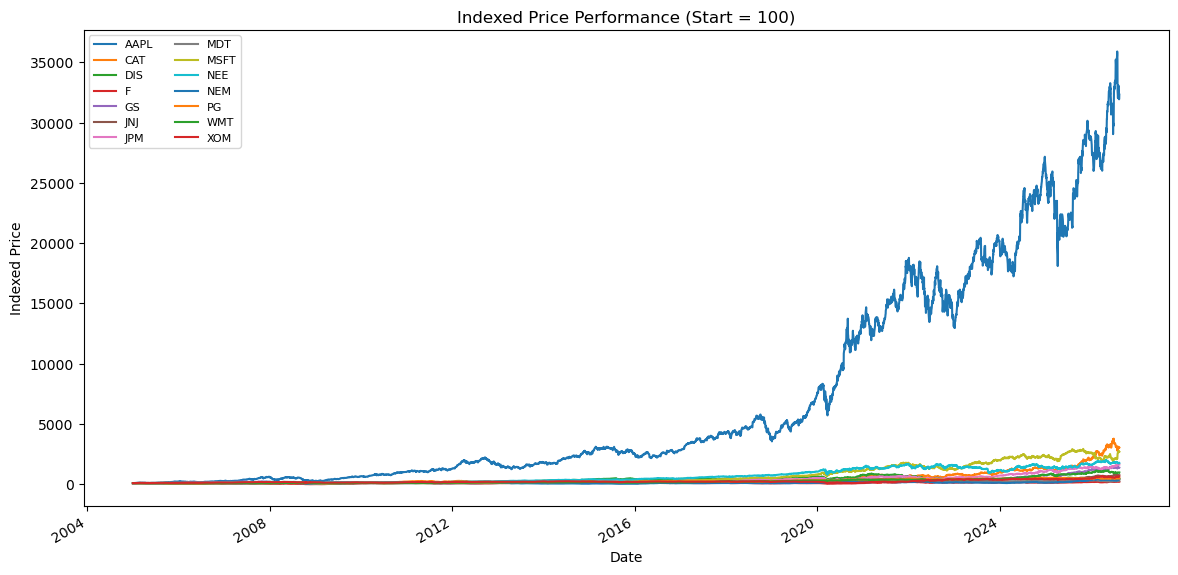

In [20]:
prices_pivot = prices_long.pivot(index='date', columns='ticker', values='close')
indexed = prices_pivot / prices_pivot.iloc[0] * 100

indexed.plot(figsize=(14, 7))
plt.title('Indexed Price Performance (Start = 100)')
plt.ylabel('Indexed Price')
plt.xlabel('Date')
plt.legend(loc='upper left', ncol=2, fontsize=8)
plt.show()

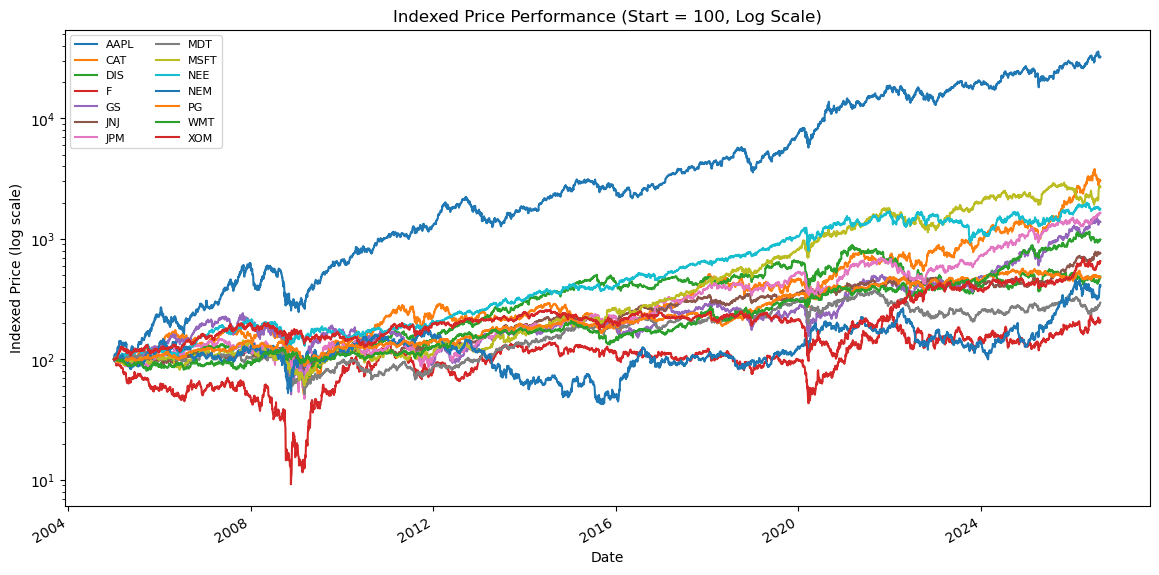

In [21]:
indexed.plot(figsize=(14, 7), logy=True)
plt.title('Indexed Price Performance (Start = 100, Log Scale)')
plt.ylabel('Indexed Price (log scale)')
plt.xlabel('Date')
plt.legend(loc='upper left', ncol=2, fontsize=8)
plt.show()

## Correlation and tails

Correlation matrix for the diversification story, skew/kurtosis per
ticker to see the fat tails directly instead of just eyeballing the
histograms above.

In [22]:
returns_wide = prices_long.pivot(index='date', columns='ticker', values='simple_return')
corr_matrix = returns_wide.corr()
corr_matrix

ticker,AAPL,CAT,DIS,F,GS,JNJ,JPM,MDT,MSFT,NEE,NEM,PG,WMT,XOM
ticker,,,,,,,,,,,,,,
AAPL,1.000000,0.397569,0.413473,0.344882,0.429920,0.299637,0.397212,0.317173,0.511232,0.293005,0.148440,0.322762,0.299117,0.328736
CAT,0.397569,1.000000,0.496609,0.465265,0.561126,0.352747,0.530270,0.381901,0.417907,0.310041,0.253312,0.309423,0.285897,0.530647
DIS,0.413473,0.496609,1.000000,0.437780,0.535021,0.383549,0.534940,0.444520,0.480145,0.376001,0.163449,0.407730,0.333667,0.474541
F,0.344882,0.465265,0.437780,1.000000,0.467490,0.267369,0.446092,0.327824,0.349041,0.263150,0.131214,0.255151,0.240006,0.354617
GS,0.429920,0.561126,0.535021,0.467490,1.000000,0.356312,0.757267,0.405212,0.462805,0.318753,0.163803,0.326907,0.296216,0.462817
JNJ,0.299637,0.352747,0.383549,0.267369,0.356312,1.000000,0.366200,0.496496,0.366154,0.442244,0.157239,0.551161,0.397858,0.406164
JPM,0.397212,0.530270,0.534940,0.446092,0.757267,0.366200,1.000000,0.410754,0.431133,0.299776,0.111473,0.369617,0.303769,0.461803
MDT,0.317173,0.381901,0.444520,0.327824,0.405212,0.496496,0.410754,1.000000,0.376660,0.394194,0.164066,0.404983,0.312815,0.406808
MSFT,0.511232,0.417907,0.480145,0.349041,0.462805,0.366154,0.431133,0.376660,1.000000,0.357913,0.180987,0.387566,0.331552,0.372094


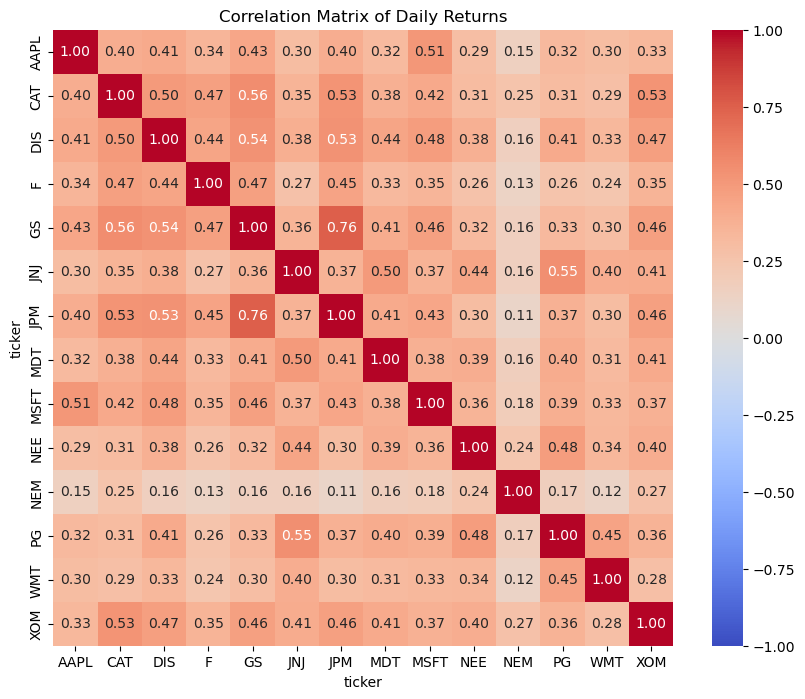

In [23]:
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix of Daily Returns')
plt.show()

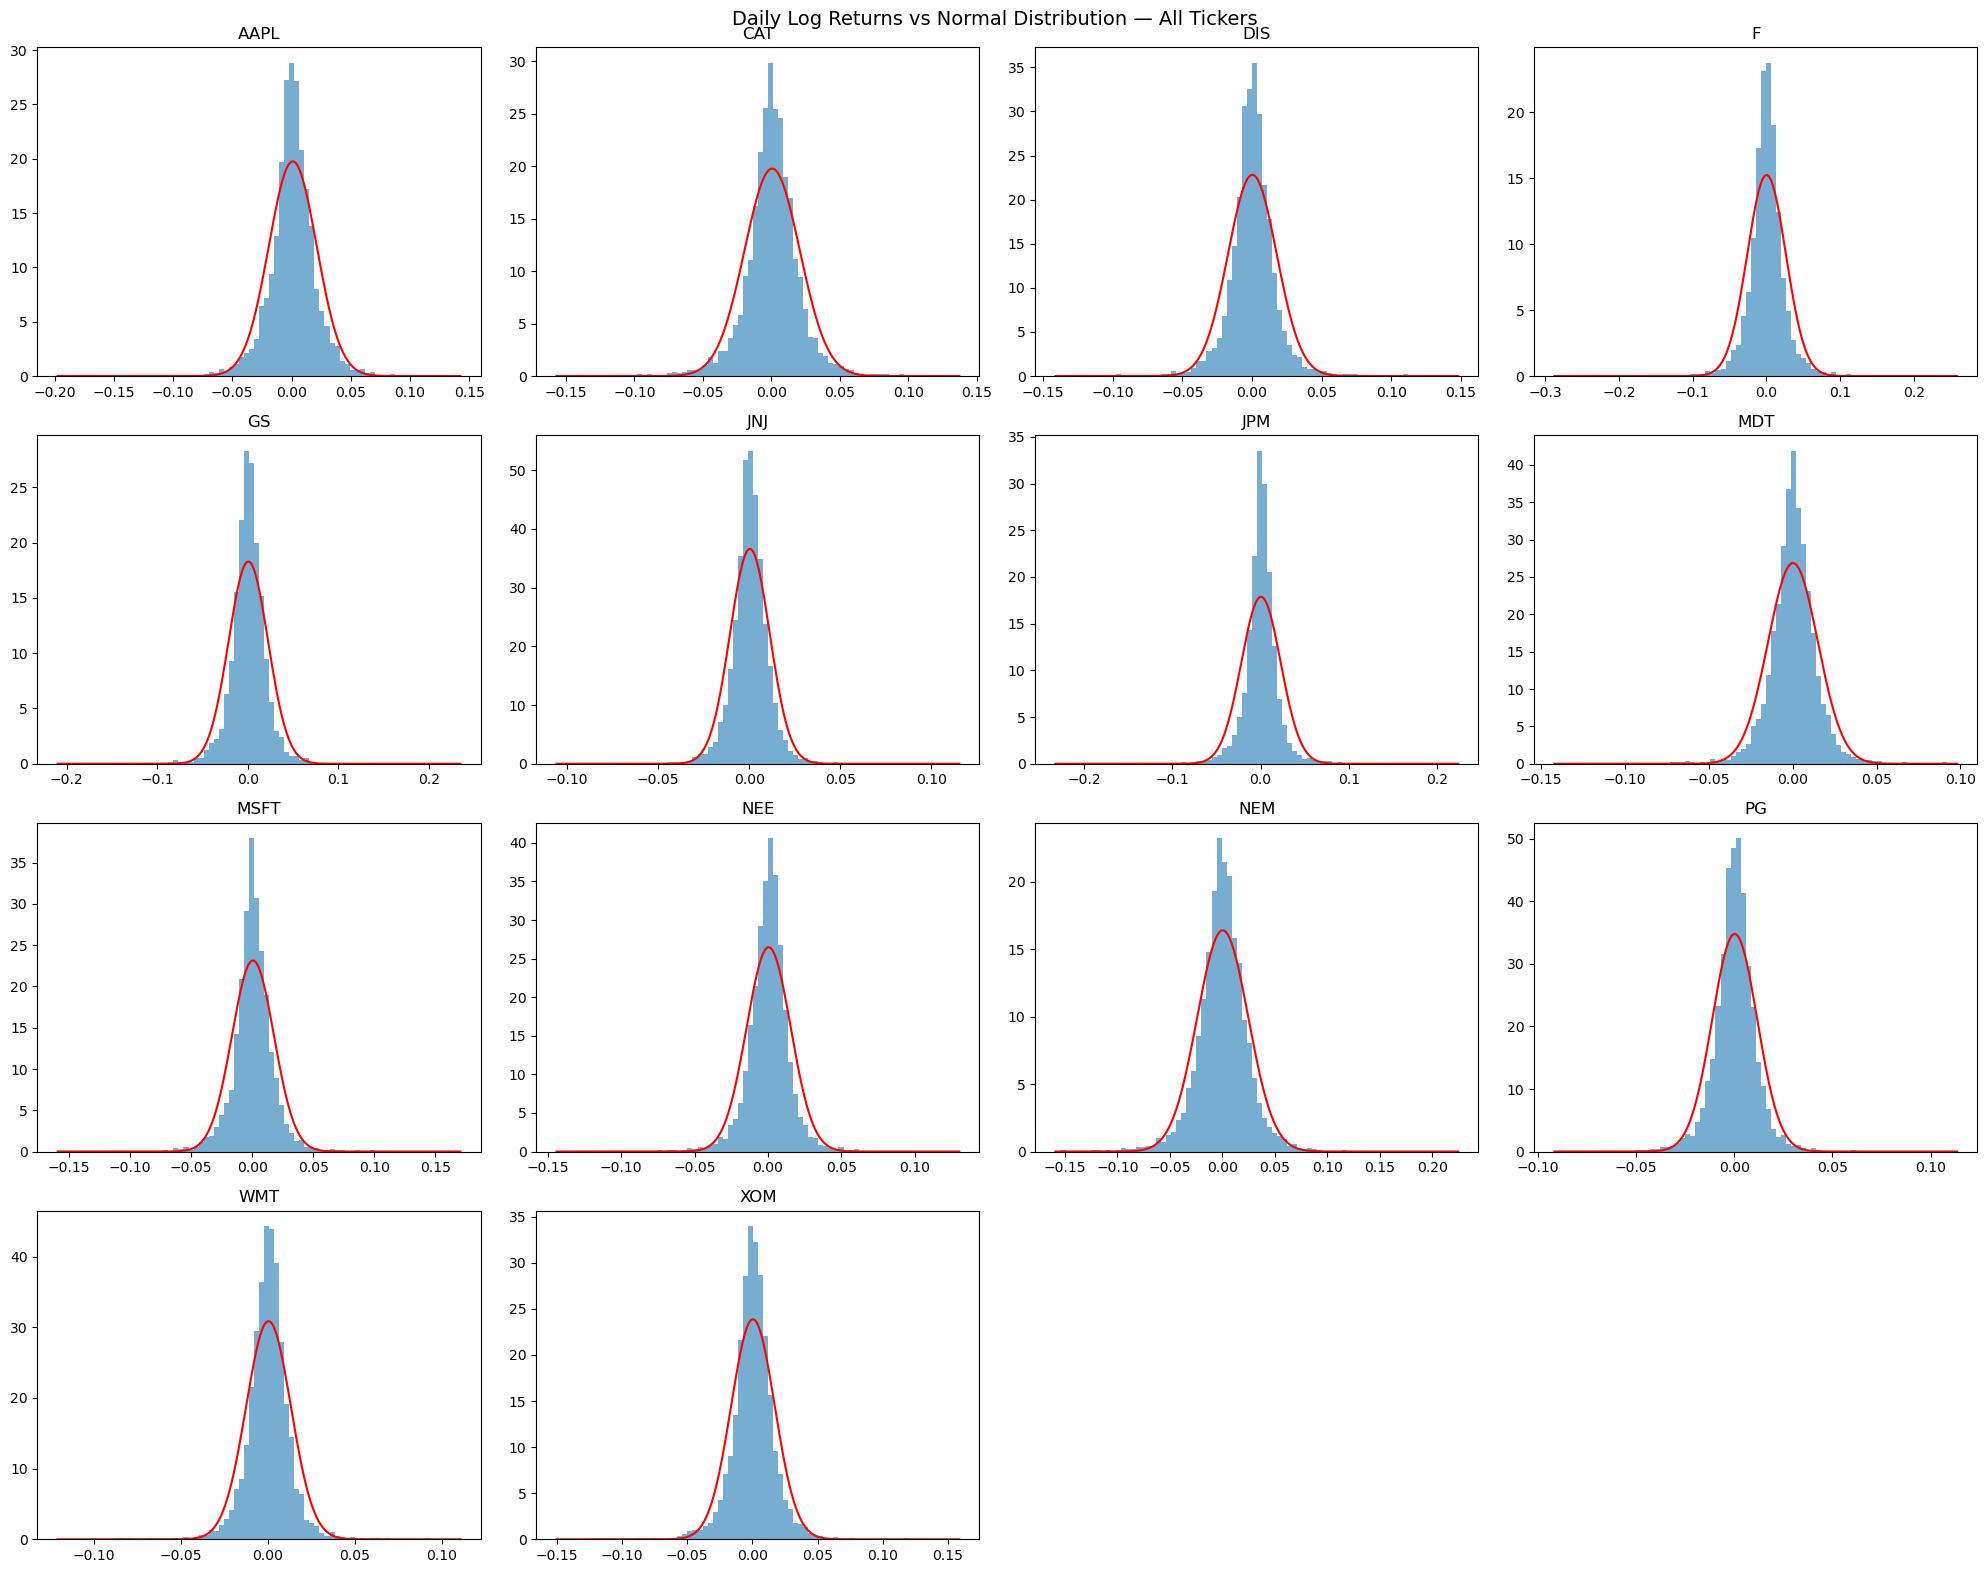

In [24]:
tickers_list = prices_long['ticker'].unique()
n = len(tickers_list)
cols = 4
rows = -(-n // cols)  # ceiling division

fig, axes = plt.subplots(rows, cols, figsize=(20, 4 * rows))
axes = axes.flatten()

for i, ticker in enumerate(tickers_list):
    returns = prices_long[prices_long['ticker'] == ticker]['log_return'].dropna()
    mu, sigma = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 200)

    axes[i].hist(returns, bins=80, density=True, alpha=0.6)
    axes[i].plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=1.5)
    axes[i].set_title(ticker)

# hide any unused subplot slots (14 tickers won't fill a perfect 4-wide grid)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Daily Log Returns vs Normal Distribution — All Tickers', fontsize=14)
plt.tight_layout()
plt.show()

In [25]:
dist_stats = prices_long.groupby('ticker')['log_return'].agg(
    skew=lambda x: stats.skew(x.dropna()),
    kurtosis=lambda x: stats.kurtosis(x.dropna())  # excess kurtosis; normal = 0
)
dist_stats

,skew,kurtosis
ticker,,
AAPL,-0.216509,6.091688
CAT,-0.197031,5.240401
DIS,0.115549,9.637527
F,-0.099058,15.323135
GS,0.173834,15.010943
JNJ,-0.029485,10.629417
JPM,0.249255,18.249810
MDT,-0.658375,10.172952
MSFT,0.049669,9.788099


## Push into Supabase

One-time backfill of the star schema for this exploration pass. The
real (idempotent, rerunnable) version of this logic is what became
`src/data_pipeline/fetch_data.py` -- this is scratch work, not meant to
be re-run as-is.

In [26]:
load_dotenv()
cfg = SupabaseConfig.from_env()
engine = create_engine(cfg.sqlalchemy_url())

with engine.connect() as conn:
    print(conn.execute(text("SELECT 1")).scalar())

1


In [27]:
dim_asset_df = pd.DataFrame([
    {"ticker": t, "company_name": v["name"], "sector": v["sector"], "market_cap_tier": v["cap"]}
    for t, v in TICKERS.items()
])

dim_asset_df.to_sql("dim_asset", engine, if_exists="append", index=False)

pd.read_sql("SELECT * FROM dim_asset", engine)

,asset_id,ticker,company_name,sector,market_cap_tier,is_active,created_at
0,1,AAPL,Apple Inc.,Technology,large,True,2026-08-15 18:15:05.391180+00:00
1,2,MSFT,Microsoft Corp.,Technology,large,True,2026-08-15 18:15:05.391180+00:00
2,3,JPM,JPMorgan Chase & Co.,Financials,large,True,2026-08-15 18:15:05.391180+00:00
3,4,GS,Goldman Sachs Group,Financials,large,True,2026-08-15 18:15:05.391180+00:00
4,5,XOM,Exxon Mobil Corp.,Energy,large,True,2026-08-15 18:15:05.391180+00:00
5,6,JNJ,Johnson & Johnson,Healthcare,large,True,2026-08-15 18:15:05.391180+00:00
6,7,MDT,Medtronic plc,Healthcare,large,True,2026-08-15 18:15:05.391180+00:00
7,8,PG,Procter & Gamble,Consumer Staples,large,True,2026-08-15 18:15:05.391180+00:00
8,9,WMT,Walmart Inc.,Consumer Staples,large,True,2026-08-15 18:15:05.391180+00:00
9,10,CAT,Caterpillar Inc.,Industrials,large,True,2026-08-15 18:15:05.391180+00:00


In [28]:
trading_dates = raw_data.index.unique()

dim_date_df = pd.DataFrame({"date_id": trading_dates})
dim_date_df["year"] = dim_date_df["date_id"].dt.year
dim_date_df["quarter"] = dim_date_df["date_id"].dt.quarter
dim_date_df["month"] = dim_date_df["date_id"].dt.month
dim_date_df["day"] = dim_date_df["date_id"].dt.day
dim_date_df["day_of_week"] = dim_date_df["date_id"].dt.dayofweek
dim_date_df["is_trading_day"] = True

dim_date_df.to_sql("dim_date", engine, if_exists="append", index=False)

pd.read_sql("SELECT COUNT(*) FROM dim_date", engine)

,count
0,5438


In [29]:
dim_portfolio_df = pd.DataFrame([{
    "portfolio_name": PORTFOLIO_NAME,
    "description": PORTFOLIO_DESCRIPTION
}])

dim_portfolio_df.to_sql("dim_portfolio", engine, if_exists="append", index=False)

pd.read_sql("SELECT * FROM dim_portfolio", engine)

,portfolio_id,portfolio_name,description,created_at
0,1,Diversified Equity Portfolio,Equal-weight 14-stock portfolio across 9 secto...,2026-08-15 18:15:07.316284+00:00


In [30]:
asset_lookup = pd.read_sql("SELECT asset_id, ticker FROM dim_asset", engine)
portfolio_id = pd.read_sql("SELECT portfolio_id FROM dim_portfolio WHERE portfolio_name = %(name)s",
                            engine, params={"name": PORTFOLIO_NAME})["portfolio_id"].iloc[0]

equal_weight = round(1 / len(TICKERS), 5)

dim_weight_df = asset_lookup.copy()
dim_weight_df["portfolio_id"] = portfolio_id
dim_weight_df["weight"] = equal_weight
dim_weight_df["effective_date"] = trading_dates.min().date()
dim_weight_df = dim_weight_df.drop(columns="ticker")

dim_weight_df.to_sql("dim_portfolio_weight", engine, if_exists="append", index=False)

pd.read_sql("SELECT * FROM dim_portfolio_weight", engine)

,portfolio_id,asset_id,weight,effective_date
0,1,1,0.07143,2005-01-03
1,1,2,0.07143,2005-01-03
2,1,3,0.07143,2005-01-03
3,1,4,0.07143,2005-01-03
4,1,5,0.07143,2005-01-03
5,1,6,0.07143,2005-01-03
6,1,7,0.07143,2005-01-03
7,1,8,0.07143,2005-01-03
8,1,9,0.07143,2005-01-03
9,1,10,0.07143,2005-01-03


In [31]:
# Reshape wide (Ticker x OHLCV columns) into long format: one row per (date, ticker)
price_long = raw_data.stack(level=0, future_stack=True)
price_long.index.names = ["date_id", "ticker"]
price_long = price_long.reset_index()

# Map ticker -> asset_id
asset_lookup = pd.read_sql("SELECT asset_id, ticker FROM dim_asset", engine)
price_long = price_long.merge(asset_lookup, on="ticker", how="left")

# Build fact_price_df matching schema.sql exactly
fact_price_df = pd.DataFrame({
    "date_id":   price_long["date_id"].dt.date,
    "asset_id":  price_long["asset_id"],
    "open":      price_long["Open"],
    "high":      price_long["High"],
    "low":       price_long["Low"],
    "close":     price_long["Close"],
    "adj_close": price_long["Close"],  # auto_adjust=True in yf.download means Close IS already adjusted
    "volume":    price_long["Volume"],
})

fact_price_df = fact_price_df.dropna(subset=["close", "adj_close"])

fact_price_df.to_sql(
    "fact_price", engine, if_exists="append", index=False,
    method="multi", chunksize=5000
)

pd.read_sql("SELECT COUNT(*) FROM fact_price", engine)

,count
0,76132


In [32]:
# Map ticker -> asset_id
asset_lookup = pd.read_sql("SELECT asset_id, ticker FROM dim_asset", engine)
returns_merged = prices_long.merge(asset_lookup, on="ticker", how="left")

# Build fact_returns_df matching schema.sql
fact_returns_df = pd.DataFrame({
    "date_id":       pd.to_datetime(returns_merged["date"]).dt.date,
    "asset_id":      returns_merged["asset_id"],
    "simple_return": returns_merged["simple_return"],
    "log_return":    returns_merged["log_return"],
})

fact_returns_df = fact_returns_df.dropna(subset=["simple_return", "log_return"])

fact_returns_df.to_sql(
    "fact_returns", engine, if_exists="append", index=False,
    method="multi", chunksize=5000
)

pd.read_sql("SELECT COUNT(*) FROM fact_returns", engine)

,count
0,76118
